# 03 - Exploratory Data Analysis (Grant Witness)
data source: grant-witness.us

## Imports

In [46]:
# imports
import pandas as pd
import re
import os
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

import torch
from transformers import AutoTokenizer
import seaborn as sns
import matplotlib.pyplot as plt


## Data

In [47]:
df_epa = pd.read_parquet('00_data/02_epa_nomic.parquet')
df_nih = pd.read_parquet('00_data/02_nih_nomic.parquet')
df_nsf = pd.read_parquet('00_data/02_nsf_nomic.parquet')
df_samhsa = pd.read_parquet('00_data/02_samhsa_nomic.parquet')
df_cdc = pd.read_parquet('00_data/02_cdc_nomic.parquet')

In [48]:
dfs = {'nih': df_nih, 'nsf': df_nsf, 'epa': df_epa, 'samhsa': df_samhsa}
dfs_titles = {'nih': df_nih, 'nsf': df_nsf, 'epa': df_epa, 'samhsa': df_samhsa, 'cdc': df_cdc}

In [49]:
dfs
common_cols = sorted(set.intersection(*(set(df.columns) for df in dfs.values())))

dfs_common = {name: df[common_cols].copy() for name, df in dfs.items()}

df_all_common = pd.concat(dfs_common.values(), ignore_index=True)

df_all_common = df_all_common.drop(columns=["Unnamed: 0"], errors="ignore")

In [63]:
df_all_common.shape

(11434, 37)

## Overview of dfs

In [50]:
dfs['all'] = df_all_common
dfs.keys()

dict_keys(['nih', 'nsf', 'epa', 'samhsa', 'all'])

In [51]:
for name, df in dfs.items():
    print(f"\n{name}")
    print("rows:", len(df))
    print("columns:", len(df.columns))
    if 'abstract' in df.columns:
        print("missing abstracts:", df["abstract"].isna().sum())
        print("missing abstracts:", df["abstract"].isna().mean())


nih
rows: 5836
columns: 79
missing abstracts: 23
missing abstracts: 0.0039410555174777245

nsf
rows: 1996
columns: 63
missing abstracts: 5
missing abstracts: 0.00250501002004008

epa
rows: 671
columns: 53
missing abstracts: 0
missing abstracts: 0.0

samhsa
rows: 2931
columns: 55
missing abstracts: 262
missing abstracts: 0.08938928693278744

all
rows: 11434
columns: 37
missing abstracts: 290
missing abstracts: 0.02536295259751618


Dropping missing abstracts

In [52]:
for name in dfs:
    if 'abstract' in df.columns:
        dfs[name] = dfs[name].dropna(subset=["abstract"])
        dfs[name] = dfs[name][dfs[name]["abstract"].astype(str).str.strip() != ""]

### Status options

In [53]:
status_counts = {}

for name, df in dfs.items():
    status_counts[name] = df['status'].value_counts()

counts_df = pd.DataFrame(status_counts).fillna(0)

counts_df = counts_df.sort_index()

In [54]:
counts_df

,nih,nsf,epa,samhsa,all
status,,,,,
Frozen Funding,157.0,0.0,0.0,0.0,157
Possibly Reinstated,2530.0,629.0,10.0,2604.0,5773
Possibly Unfrozen Funding,951.0,0.0,0.0,0.0,951
Reinstated,0.0,0.0,54.0,24.0,78
Terminated,1069.0,1362.0,607.0,41.0,3079
Unfrozen Funding,1106.0,0.0,0.0,0.0,1106


In [18]:
color_map = {
    'Terminated': 'black',
    'Frozen Funding': '#4d4d4d',              # dark grey
    'Possibly Unfrozen Funding': '#9ecae1',   # light blue
    'Unfrozen Funding': '#3182bd',            # stronger blue
    'Possibly Reinstated': '#a1d99b',         # light green
    'Reinstated': '#006d2c',                  # dark green (best outcome)
}

status_order = [
    'Terminated',
    'Frozen Funding',
    'Possibly Unfrozen Funding',
    'Unfrozen Funding',
    'Possibly Reinstated',
    'Reinstated',
]

wrapped_labels = {
    'Terminated': 'Terminated',
    'Frozen Funding': 'Frozen\nFunding',
    'Possibly Unfrozen Funding': 'Possibly\nUnfrozen\nFunding',
    'Unfrozen Funding': 'Unfrozen\nFunding',
    'Possibly Reinstated': 'Possibly\nReinstated',
    'Reinstated': 'Reinstated'
}

In [19]:
counts_df = counts_df.reindex(status_order).fillna(0)

colors = [color_map[s] for s in counts_df.index]

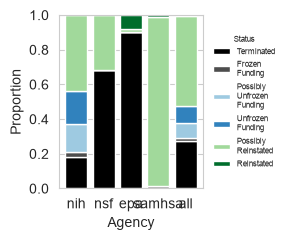

In [20]:
sns.set_style('whitegrid')

relative_df = counts_df.div(counts_df.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(3, 2.5))

bottom = pd.Series(0, index=relative_df.columns)

for status in relative_df.index:
    values = relative_df.loc[status]
    ax.bar(relative_df.columns, values,
           bottom=bottom,
           color=color_map[status],
           label=wrapped_labels[status])
    bottom += values

ax.set_ylabel('Proportion')
ax.set_xlabel('Agency')
ax.set_title('')

ax.legend(
    title='Status',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=6,
    title_fontsize=6
)

plt.tight_layout()

plt.show()

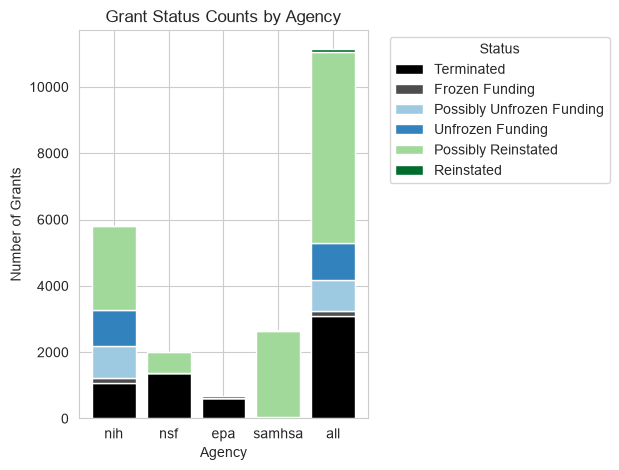

In [21]:
fig, ax = plt.subplots()

bottom = None

for status in counts_df.index:
    values = counts_df.loc[status]
    
    if bottom is None:
        ax.bar(counts_df.columns, values,
               color=color_map[status],
               label=status)
        bottom = values
    else:
        ax.bar(counts_df.columns, values,
               bottom=bottom,
               color=color_map[status],
               label=status)
        bottom += values

ax.set_ylabel("Number of Grants")
ax.set_xlabel("Agency")
ax.set_title("Grant Status Counts by Agency")
ax.legend(title="Status", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Do grants with flagged words get terminated more often?

In [23]:
df_all_common.columns

Index(['abstract', 'agency', 'avg_repetition', 'award_amount', 'award_outlaid',
       'award_remaining', 'flagged_words_all_abstract',
       'flagged_words_all_title', 'grant_id', 'has_flagged_terms_total',
       'has_flagged_word_total', 'org_city', 'org_name', 'org_state',
       'project_title', 'reinstatement_date', 'reinstatement_indicator',
       'start_date_original', 'status', 'termination_date',
       'total_flagged_terms_abstract', 'total_flagged_terms_title',
       'total_flagged_terms_total', 'total_nyt_terms_abstract',
       'total_nyt_terms_title', 'total_pen_terms_abstract',
       'total_pen_terms_title', 'unique_flagged_words_abstract',
       'unique_flagged_words_title', 'unique_flagged_words_total',
       'unique_nyt_words_abstract', 'unique_nyt_words_title',
       'unique_pen_words_abstract', 'unique_pen_words_title',
       'usaspending_url'],
      dtype='str')

In [26]:
df_all_common.groupby('status')['total_flagged_terms_total'].mean()

status
Frozen Funding                5.184713
Possibly Reinstated          12.319966
Possibly Unfrozen Funding     4.798319
Reinstated                    0.000000
Terminated                   14.586499
Unfrozen Funding              4.991885
Name: total_flagged_terms_total, dtype: float64

In [27]:
df_all_common.groupby('status')['total_flagged_terms_title'].mean()

status
Frozen Funding               0.089172
Possibly Reinstated          0.103993
Possibly Unfrozen Funding    0.075630
Reinstated                   0.000000
Terminated                   0.148195
Unfrozen Funding             0.087466
Name: total_flagged_terms_title, dtype: float64

## Overview of abstracts

How are abstracts distributed? What is the quality of data?

In [28]:
def add_word_count(df):
    df['abstract_word_count'] = (
        df['abstract']
        .fillna('')
        .astype(str)
        .str.split()
        .str.len()
    )
    return df

df_nih = add_word_count(df_nih)
df_epa = add_word_count(df_epa)
df_nsf = add_word_count(df_nsf)
df_samhsa = add_word_count(df_samhsa)

df_all_common = add_word_count(df_all_common)
df_all_common['abstract_word_count'].describe()

count    11434.000000
mean       386.432482
std        130.366411
min          0.000000
25%        327.000000
50%        411.000000
75%        461.000000
max       3285.000000
Name: abstract_word_count, dtype: float64

In [29]:
def add_word_count(df):
    df['title_word_count'] = (
        df['project_title']
        .fillna('')
        .astype(str)
        .str.split()
        .str.len()
    )
    return df

df_nih = add_word_count(df_nih)
df_epa = add_word_count(df_epa)
df_nsf = add_word_count(df_nsf)
df_samhsa = add_word_count(df_samhsa)

df_all_common = add_word_count(df_all_common)
df_all_common['title_word_count'].describe()

count    11434.000000
mean        10.640721
std          4.778813
min          0.000000
25%          7.000000
50%         10.000000
75%         14.000000
max         30.000000
Name: title_word_count, dtype: float64

Average flagged words breakdown per agency

In [36]:
df_all_common.columns

Index(['abstract', 'agency', 'avg_repetition', 'award_amount', 'award_outlaid',
       'award_remaining', 'flagged_words_all_abstract',
       'flagged_words_all_title', 'grant_id', 'has_flagged_terms_total',
       'has_flagged_word_total', 'org_city', 'org_name', 'org_state',
       'project_title', 'reinstatement_date', 'reinstatement_indicator',
       'start_date_original', 'status', 'termination_date',
       'total_flagged_terms_abstract', 'total_flagged_terms_title',
       'total_flagged_terms_total', 'total_nyt_terms_abstract',
       'total_nyt_terms_title', 'total_pen_terms_abstract',
       'total_pen_terms_title', 'unique_flagged_words_abstract',
       'unique_flagged_words_title', 'unique_flagged_words_total',
       'unique_nyt_words_abstract', 'unique_nyt_words_title',
       'unique_pen_words_abstract', 'unique_pen_words_title',
       'usaspending_url', 'abstract_word_count', 'title_word_count'],
      dtype='str')

In [37]:
summary = pd.DataFrame([
    {
        "agency": name,
        "rows": len(df),
        "pct_flagged": df["has_flagged_terms_total"].mean(),
        "avg_flagged_words": df["total_flagged_terms_total"].mean(),
        "avg_flagged_words_title": df["total_flagged_terms_title"].mean(),
        "avg_pen_words": df["total_pen_terms_title"].mean(),
        "avg_nyt_words": df["total_nyt_terms_title"].mean()
    }
    for name, df in dfs.items()
])

summary

,agency,rows,pct_flagged,avg_flagged_words,avg_flagged_words_title,avg_pen_words,avg_nyt_words
0,nih,5813,0.808705,8.243764,0.168416,0.094443,0.073972
1,nsf,1991,0.923154,19.506278,0.141135,0.078855,0.062280
2,epa,671,0.007452,0.010432,0.010432,0.008942,0.001490
3,samhsa,2669,0.957662,16.153616,0.000000,0.000000,0.000000
4,all,11144,0.816583,11.654612,0.113693,0.063891,0.049803


In [39]:
for name, df in dfs.items():
    print(f'\n{name}')
    print('Has flagged word:', df['has_flagged_terms_total'].mean())
    print('Avg # flagged words:', df['total_flagged_terms_total'].mean())
    print('Has flagged word in title:', df['total_flagged_terms_title'].mean())


nih
Has flagged word: 0.8087046275589197
Avg # flagged words: 8.243763977292275
Has flagged word in title: 0.16841562016170653

nsf
Has flagged word: 0.9231541938724259
Avg # flagged words: 19.506278252134607
Has flagged word in title: 0.1411351079859367

epa
Has flagged word: 0.007451564828614009
Avg # flagged words: 0.010432190760059613
Has flagged word in title: 0.010432190760059613

samhsa
Has flagged word: 0.9576620457100038
Avg # flagged words: 16.153615586361934
Has flagged word in title: 0.0

all
Has flagged word: 0.8165829145728644
Avg # flagged words: 11.654612347451543
Has flagged word in title: 0.11369346733668342


### Checking duplicate abstracts

In [41]:
df_all_common["abstract"].value_counts().head(10)

abstract
DESCRIPTION:NOTE: A SPECIAL PAYMENT CONDITION APPLIES TO THIS AWARD.\n\nTHIS AGREEMENT PROVIDES FUNDING UNDER THE INFLATION REDUCTION ACT. THE RECIPIENT WILL PROVIDE FINANCIAL AND TECHNICAL ASSISTANCE TO LOW-INCOME AND DISADVANTAGED COMMUNITIES TO DEPLOY AND BENEFIT FROM RESIDENTIAL-SERVING DISTRIBUTED SOLAR ENERGY AND STORAGE PROJECTS. THESE PROGRAMS WILL ENSURE LOW-INCOME HOUSEHOLDS RECEIVE RESIDENTIAL DISTRIBUTED SOLAR BY PROVIDING PROGRAM BENEFICIARIES HOUSEHOLD SAVINGS, COMMUNITY OWNERSHIP, ENERGY RESILIENCE, AND OTHER MEANINGFUL BENEFITS.\nACTIVITIES:SOLAR PROJECTS RECEIVING FINANCIAL ASSISTANCE FROM THE RECIPIENT MAY RECEIVE ASSISTANCE FOR ASSOCIATED ENERGY STORAGE AND UPGRADES THAT EITHER ENABLE PROJECT DEPLOYMENT OR MAXIMIZE THE BENEFITS OF THE PROJECT FOR LOW-INCOME AND DISADVANTAGED COMMUNITIES. THE RECIPIENT WILL ALSO PROVIDE PROJECT-DEPLOYMENT SERVICES TO ENABLE LOW-INCOME AND DISADVANTAGED COMMUNITIES TO DEPLOY AND BENEFIT FROM RESIDENTIAL SOLAR.SUBRECIPIENT:NO S

Binary adverse outcome var

In [42]:
df_all_common["status"].value_counts(normalize=True)

status
Possibly Reinstated          0.514693
Terminated                   0.278555
Unfrozen Funding             0.096991
Possibly Unfrozen Funding    0.083260
Frozen Funding               0.013731
Reinstated                   0.012769
Name: proportion, dtype: float64

In [28]:
adverse_statuses = ['Terminated', 'Frozen Funding']

df_all_common['target_adverse'] = df_all_common['status'].isin(adverse_statuses).astype(int)

In [44]:
df_all_common["target_adverse"].value_counts(normalize=True)

target_adverse
0    0.707714
1    0.292286
Name: proportion, dtype: float64

## Embeddings analysis

Norms

In [16]:
for name, df in dfs.items():
    if 'abstract_embeddings_nomic' in df.columns:
        non_null = df['abstract_embeddings_nomic'].dropna()
        if non_null.empty:
            continue
        norms = np.linalg.norm(np.vstack(non_null.tolist()), axis=1)
        print(name, norms.min(), norms.mean(), norms.max())


nih 0.9999998906017602 0.9999999996200698 1.0000001023583776
nsf 0.9999999099298932 0.9999999986161834 1.000000087111621
epa 0.9999999229893477 1.0000000000540845 1.0000000809349225
samhsa 0.9999999025753443 0.9999999979492536 1.000000084493741


## PCA

In [29]:
df_nona = df_all_common[df_all_common['abstract'].notna()]
df_nona

,abstract,abstract_embeddings_nomic,agency,avg_repetition,award_amount,award_outlaid,award_remaining,flagged_words_all_abstract,flagged_words_all_title,grant_id,...,total_pen_terms_title,unique_flagged_words_abstract,unique_flagged_words_title,unique_flagged_words_total,unique_nyt_words_abstract,unique_nyt_words_title,unique_pen_words_abstract,unique_pen_words_title,usaspending_url,target_adverse
3,PROJECT SUMMARY This institutional grant propo...,"[0.019225066527724266, 0.1197880282998085, -0....",NIH,1.000000,8000000.00,8000000.00,0.00,institutional,institutional,C06OD030152,...,0,1,1,2,1,1,1,1,https://www.usaspending.gov/award/ASST_NON_C06...,0
4,Project Summary/Abstract Wards 7 and 8 in Wash...,"[0.0020422835368663073, 0.09004892408847809, -...",NIH,2.100000,2000000.00,618137.31,1381862.69,community; inequities; integration; marginaliz...,community,C06OD034040,...,0,9,1,10,6,0,8,1,https://www.usaspending.gov/award/ASST_NON_C06...,0
5,Project Summary The goal of the proposed HIV/...,"[-0.012400302104651928, 0.06091583892703056, -...",NIH,1.642857,113750.86,113750.86,0.00,barriers; bipoc; black; community; covid-19; h...,NaN,C06OD034042,...,0,14,0,14,9,0,14,0,https://www.usaspending.gov/award/ASST_NON_C06...,1
7,PROJECT SUMMARY The Northwestern University (N...,"[-0.0009703771211206913, 0.048112306743860245,...",NIH,0.000000,1302310.00,933861.02,368448.98,NaN,NaN,D43CA260658,...,0,0,0,0,0,0,0,0,https://www.usaspending.gov/award/ASST_NON_D43...,0
8,Project Summary/Abstract HIV-related brain dis...,"[0.026901820674538612, 0.06724044680595398, -0...",NIH,3.500000,3643159.00,830968.51,2812190.49,at risk; gender; mental health; minority,NaN,D43TW009608,...,0,4,0,4,4,0,4,0,https://www.usaspending.gov/award/ASST_NON_D43...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11403,The Gay and Lesbian Community Center of Southe...,"[-0.011459187604486942, 0.07353552430868149, -...",SAMHSA,1.266667,1399951.00,627976.17,771974.83,at risk; black; community; female; gay; gender...,minority,TI088031,...,0,14,1,15,10,1,14,1,https://www.usaspending.gov/award/ASST_NON_H79...,0
11404,The American Academy of Addiction Psychiatry (...,"[-0.020633738487958908, 0.03923909738659859, -...",SAMHSA,2.153846,37000000.00,9429793.33,27570206.67,black; community; continuum; culturally respon...,tribal,TI088037,...,0,12,1,13,8,1,12,1,https://www.usaspending.gov/award/ASST_NON_H79...,0
11405,"The Ali Forney Center (AFC), the largest provi...","[-0.02132534794509411, 0.06883826851844788, -0...",SAMHSA,1.538462,1399980.00,358000.00,1041980.00,bipoc; bisexual; black; gay; indigenous; lesbi...,minority,TI088051,...,0,12,1,13,8,1,12,1,https://www.usaspending.gov/award/ASST_NON_H79...,0
11406,In response to the U.S. Department of Health a...,"[0.0075111594051122665, 0.027737023308873177, ...",SAMHSA,1.789474,1400000.00,406761.00,993239.00,at risk; bisexual; black; community; culturall...,minority,TI088072,...,0,18,1,19,13,1,18,1,https://www.usaspending.gov/award/ASST_NON_H79...,0


prep matrices

In [30]:
X_abs = np.vstack(df_nona['abstract_embeddings_nomic'].tolist())
X_title = np.vstack(df_nona['title_embeddings_nomic'].tolist())

In [31]:
pca_abs = PCA(n_components=10)
X_abs_pca = pca_abs.fit_transform(X_abs)

pca_title = PCA(n_components=10)
X_title_pca = pca_title.fit_transform(X_title)

print("Abstract:", pca_abs.explained_variance_ratio_)
print("Title:", pca_title.explained_variance_ratio_)

Abstract: [0.12540415 0.07522284 0.04029909 0.03738185 0.03002851 0.02680907
 0.02167986 0.02050717 0.01841846 0.01649291]
Title: [0.08452394 0.05244589 0.03499352 0.03081801 0.0233945  0.02273736
 0.0217206  0.01934375 0.0187764  0.01764881]


In [32]:
explained_abs = pca_abs.explained_variance_ratio_
cum_abs = np.cumsum(explained_abs)

explained_title = pca_title.explained_variance_ratio_
cum_title = np.cumsum(explained_title)

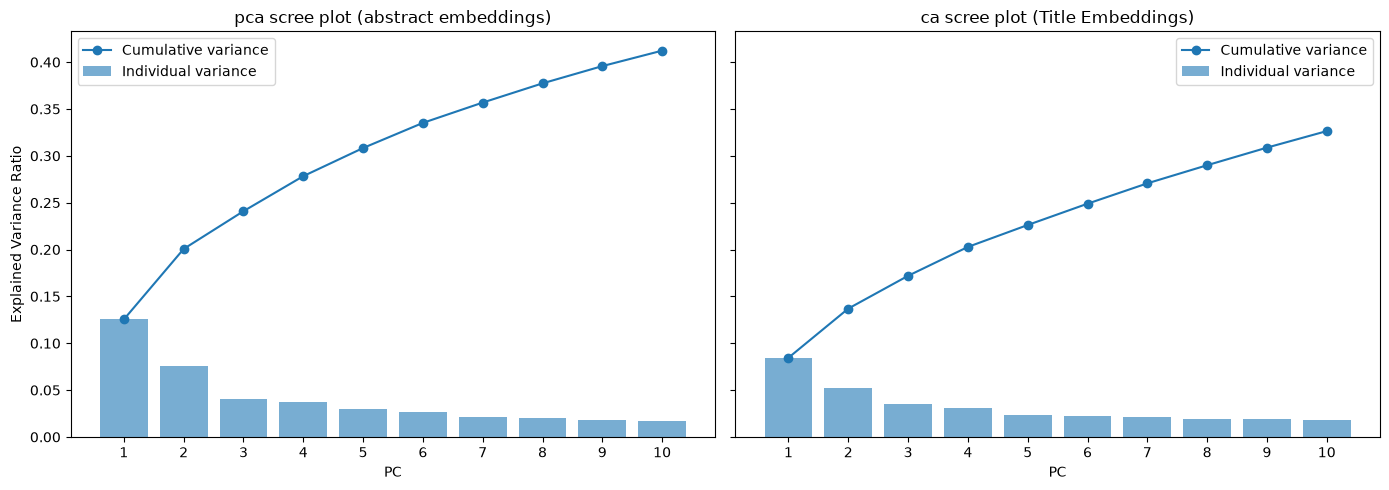

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(range(1, len(explained_abs)+1), explained_abs, alpha=0.6, label='Individual variance')
axes[0].plot(range(1, len(explained_abs)+1), cum_abs, marker='o', label='Cumulative variance')
axes[0].set_title('pca scree plot (abstract embeddings)')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xticks(range(1, len(explained_abs)+1))
axes[0].legend()

axes[1].bar(range(1, len(explained_title)+1), explained_title, alpha=0.6, label='Individual variance')
axes[1].plot(range(1, len(explained_title)+1), cum_title, marker='o', label='Cumulative variance')
axes[1].set_title('ca scree plot (Title Embeddings)')
axes[1].set_xlabel('PC')
axes[1].set_xticks(range(1, len(explained_title)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

Pca projection

In [34]:
X_abs = np.vstack(df_nona['abstract_embeddings_nomic'].tolist())
pca_abs = PCA(n_components=10)
X_abs_pca = pca_abs.fit_transform(X_abs)

In [35]:
X_title = np.vstack(df_nona['title_embeddings_nomic'].tolist())
pca_title = PCA(n_components=10)
X_title_pca = pca_title.fit_transform(X_title)

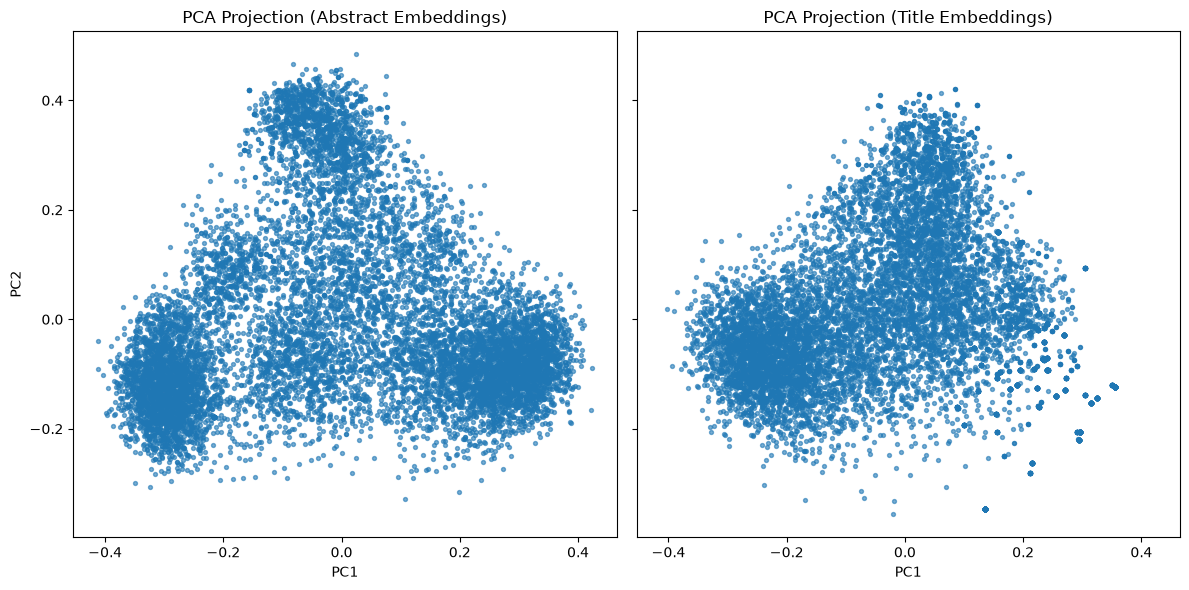

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

axes[0].scatter(X_abs_pca[:, 0], X_abs_pca[:, 1], s=8, alpha=0.6)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Projection (Abstract Embeddings)")

axes[1].scatter(X_title_pca[:, 0], X_title_pca[:, 1], s=8, alpha=0.6)
axes[1].set_xlabel("PC1")
axes[1].set_title("PCA Projection (Title Embeddings)")

plt.tight_layout()
plt.show()

By adverse outcome binary

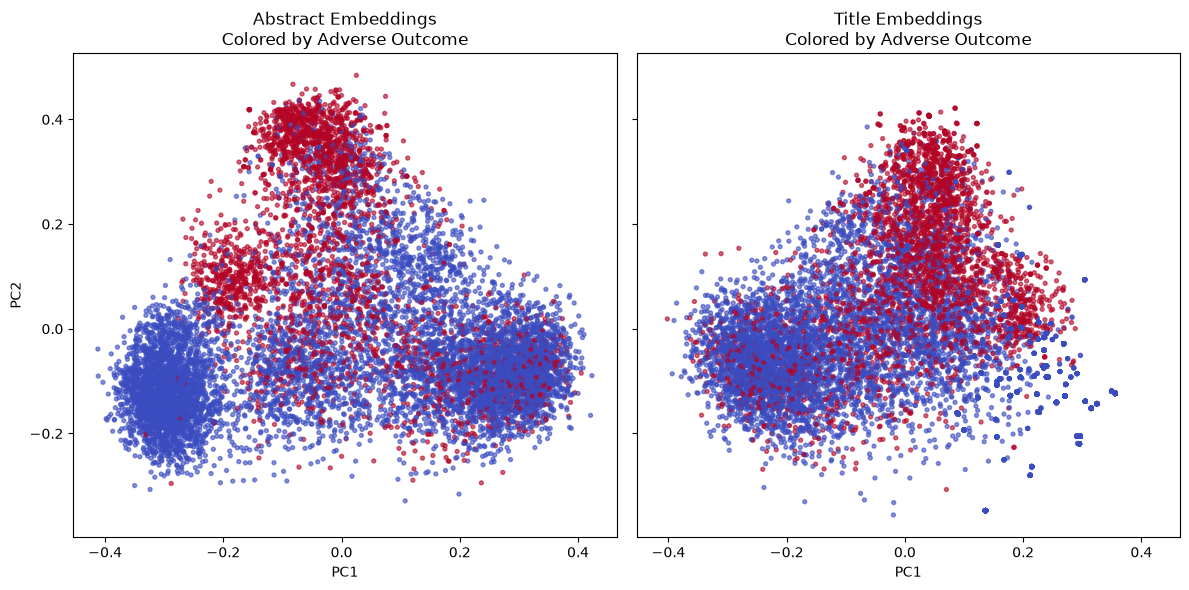

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

axes[0].scatter(
    X_abs_pca[:, 0],
    X_abs_pca[:, 1],
    c=df_nona['target_adverse'],
    cmap='coolwarm',
    s=8,
    alpha=0.6
)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Abstract Embeddings\nColored by Adverse Outcome')

scatter = axes[1].scatter(
    X_title_pca[:, 0],
    X_title_pca[:, 1],
    c=df_nona['target_adverse'],
    cmap='coolwarm',
    s=8,
    alpha=0.6
)

axes[1].set_xlabel('PC1')
axes[1].set_title('Title Embeddings\nColored by Adverse Outcome')


plt.tight_layout()
plt.show()

By status

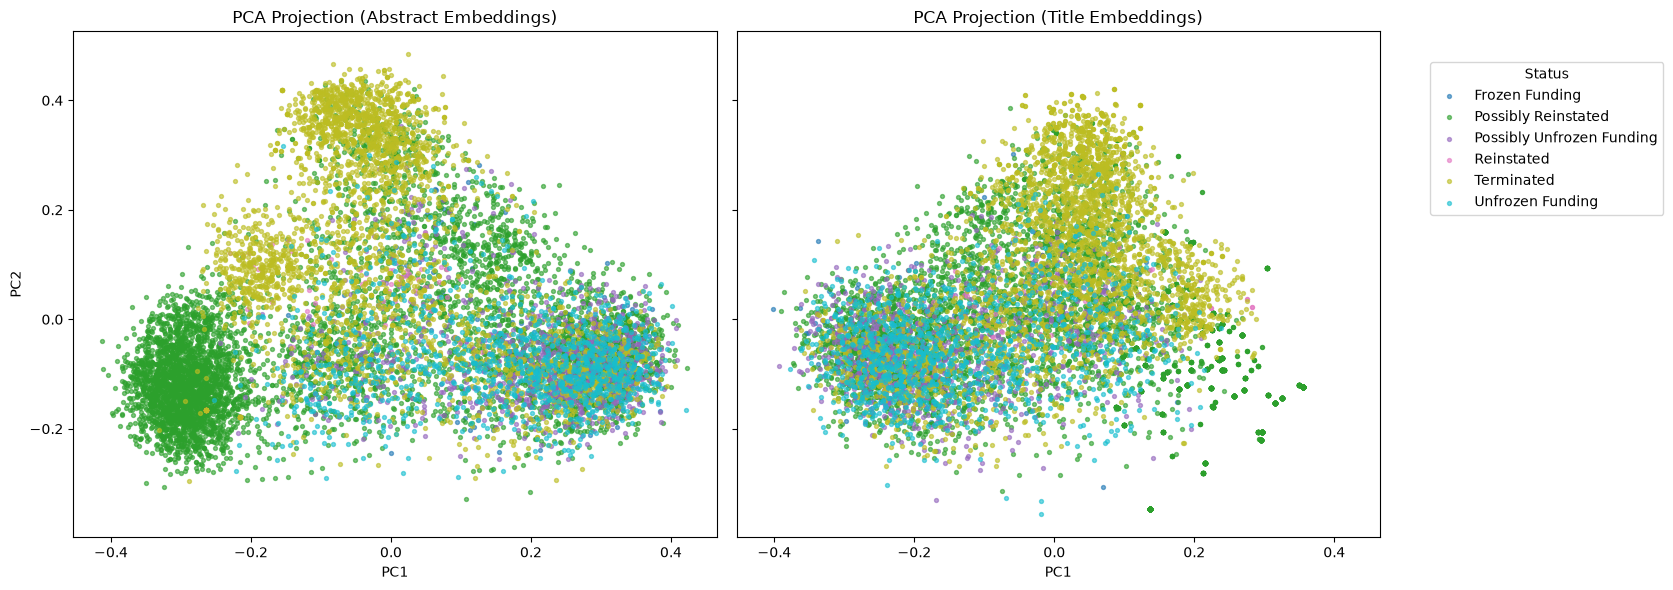

In [ ]:
df_nona["status"] = df_nona["status"].astype("category")

statuses = df_nona["status"].cat.categories

colors = plt.cm.tab10(np.linspace(0, 1, len(statuses)))
color_dict = dict(zip(statuses, colors))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for status in statuses:
    mask = df_nona["status"] == status
    axes[0].scatter(
        X_abs_pca[mask, 0],
        X_abs_pca[mask, 1],
        label=status,
        color=color_dict[status],
        s=8,
        alpha=0.6
    )

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Projection (Abstract Embeddings)")

for status in statuses:
    mask = df_nona["status"] == status
    axes[1].scatter(
        X_title_pca[mask, 0],
        X_title_pca[mask, 1],
        label=status,
        color=color_dict[status],
        s=8,
        alpha=0.6
    )

axes[1].set_xlabel("PC1")
axes[1].set_title("PCA Projection (Title Embeddings)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Status", bbox_to_anchor=(1.02, 0.9), loc="upper left")

plt.tight_layout()
plt.show()

## t-SNE

In [40]:
df_plot = df_nona.sample(1000, random_state=42).copy()

X_abs = np.vstack(df_plot['abstract_embeddings_nomic'].tolist())

tsne_abs = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne_abs = tsne_abs.fit_transform(X_abs)

df_plot['tsne_abs_x'] = X_tsne_abs[:, 0]
df_plot['tsne_abs_y'] = X_tsne_abs[:, 1]

X_title = np.vstack(df_plot['title_embeddings_nomic'].tolist())

tsne_title = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne_title = tsne_title.fit_transform(X_title)

df_plot['tsne_title_x'] = X_tsne_title[:, 0]
df_plot['tsne_title_y'] = X_tsne_title[:, 1]

/var/folders/f0/g61h031s7yscf43_m6xj3l0c0000gn/T/ipykernel_30324/1702057206.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


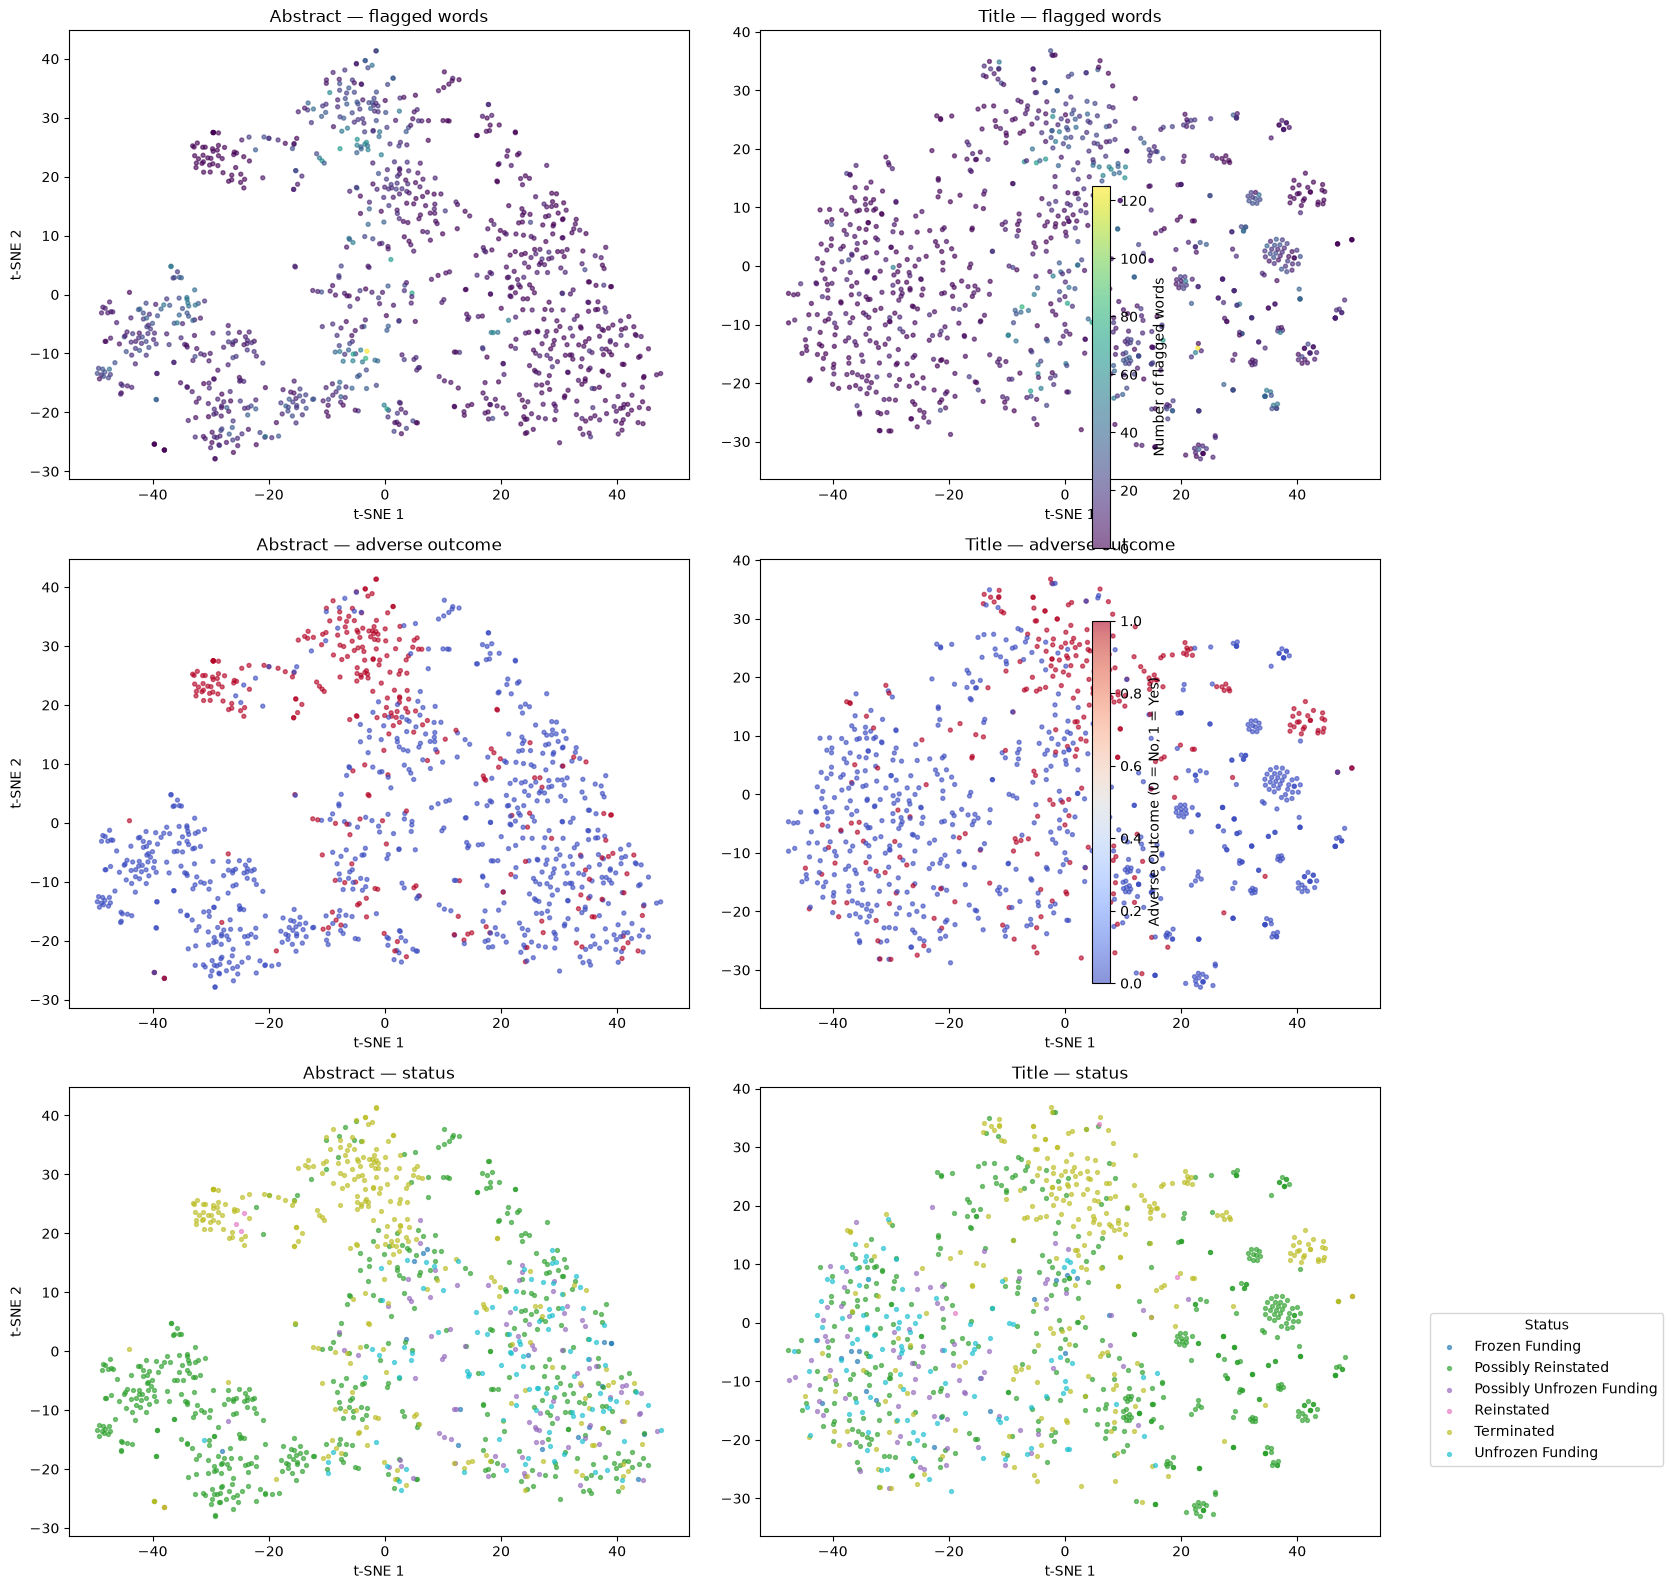

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

sc0 = axes[0, 0].scatter(
    df_plot['tsne_abs_x'], df_plot['tsne_abs_y'],
    c=df_plot['total_flagged_terms_total'], cmap='viridis', s=8, alpha=0.6
)
axes[0, 0].set_title('Abstract — flagged words')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')

sc0b = axes[0, 1].scatter(
    df_plot['tsne_title_x'], df_plot['tsne_title_y'],
    c=df_plot['total_flagged_terms_total'], cmap='viridis', s=8, alpha=0.6
)
axes[0, 1].set_title('Title — flagged words')
axes[0, 1].set_xlabel('t-SNE 1')
fig.colorbar(sc0b, ax=axes[0, :].tolist(), pad=0.02, label='Number of flagged words')

sc1 = axes[1, 0].scatter(
    df_plot['tsne_abs_x'], df_plot['tsne_abs_y'],
    c=df_plot['target_adverse'], cmap='coolwarm', s=8, alpha=0.6
)
axes[1, 0].set_title('Abstract — adverse outcome')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')

sc1b = axes[1, 1].scatter(
    df_plot['tsne_title_x'], df_plot['tsne_title_y'],
    c=df_plot['target_adverse'], cmap='coolwarm', s=8, alpha=0.6
)
axes[1, 1].set_title('Title — adverse outcome')
axes[1, 1].set_xlabel('t-SNE 1')
fig.colorbar(sc1b, ax=axes[1, :].tolist(), pad=0.02, label='Adverse Outcome (0 = No, 1 = Yes)')

for status in statuses:
    mask = df_plot['status'] == status
    axes[2, 0].scatter(
        df_plot.loc[mask, 'tsne_abs_x'], df_plot.loc[mask, 'tsne_abs_y'],
        s=8, alpha=0.6, color=color_dict[status], label=status
    )
    axes[2, 1].scatter(
        df_plot.loc[mask, 'tsne_title_x'], df_plot.loc[mask, 'tsne_title_y'],
        s=8, alpha=0.6, color=color_dict[status], label=status
    )

axes[2, 0].set_title('Abstract — status')
axes[2, 0].set_xlabel('t-SNE 1')
axes[2, 0].set_ylabel('t-SNE 2')
axes[2, 1].set_title('Title — status')
axes[2, 1].set_xlabel('t-SNE 1')
handles, labels = axes[2, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Status', bbox_to_anchor=(1.02, 0.18), loc='upper left')

plt.tight_layout()
plt.show()


In [45]:
df_all_common['grant_id'] = df_all_common['grant_id'].astype(str)
df_all_common.to_parquet('00_data/03_full.parquet')

# Next: 04_modeling